###Import all the necessary python libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

###Mount drive on google colab (if using google colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load and explore the dataset

In [ ]:
## have a look at the dataset and confirm that all features are boolean values (just 0's and 1's)

df = pd.read_csv("/content/drive/MyDrive/F23 38-615 09-615 HWs/Homeworks/HW2/hw2_dataset.csv")
#df = pd.read_csv("hw2_dataset.csv")    #on your local jupyter notebook
print()
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Columns: 1025 entries, ID to D_1023
dtypes: int64(1024), object(1)
memory usage: 7.6+ MB
None


,ID,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,...,D_1014,D_1015,D_1016,D_1017,D_1018,D_1019,D_1020,D_1021,D_1022,D_1023
0,AAEAMMIUQZAASJ-MRXNPFEDSA-N,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
1,AAEFNWQXBPYXAC-UHFFFAOYSA-N,1,1,1,1,0,1,1,1,0,...,1,0,1,1,1,0,0,1,1,1
2,AAMHSIWFDKXUMZ-UHFFFAOYSA-N,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,0,0,1,1
3,AAPQXEOSVSLLMB-UHFFFAOYSA-N,1,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,AARXXEHXOBTROW-UHFFFAOYSA-N,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1


In [ ]:
## check for null/missing values

df.isnull().any().sum()

0

In [ ]:
## extract everything except the "ID" feature

data = df.iloc[:,1:].to_numpy()
print(data)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 0 1 1]
 ...
 [1 0 1 ... 0 0 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 0 1 1]]


In [ ]:
## check if values in all columns are equal to 0 or 1
is_one = df.applymap(lambda x: x == 1)
is_zero = df.applymap(lambda x: x == 0)

# count the number of True and False values along each column
true_count = is_one.sum(axis=0)
false_count = is_zero.sum(axis=0)

In [ ]:
true_count

ID          0
D_0       969
D_1       873
D_2       969
D_3       969
         ... 
D_1019    660
D_1020    536
D_1021    784
D_1022    796
D_1023    884
Length: 1025, dtype: int64

In [ ]:
false_count

ID          0
D_0         0
D_1        96
D_2         0
D_3         0
         ... 
D_1019    309
D_1020    433
D_1021    185
D_1022    173
D_1023     85
Length: 1025, dtype: int64

### Perform k-means clustering. Determine the optimal number of clusters using e.g. elbow method

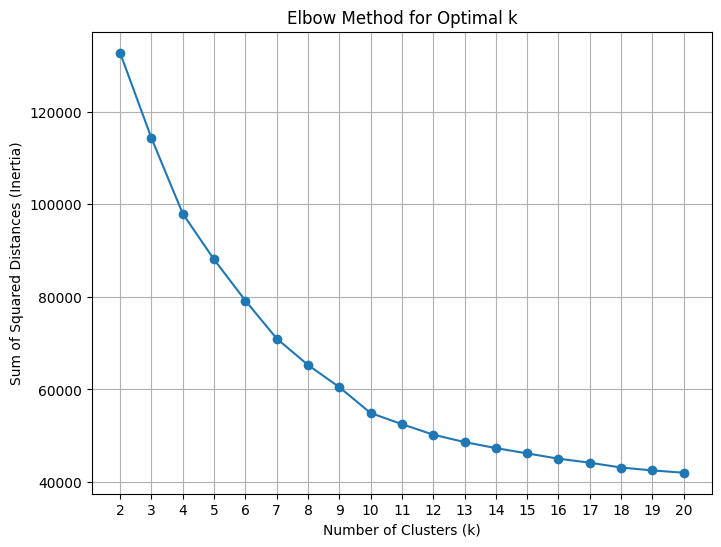

In [ ]:
## sum of squared distances (inertia) for each k
inertia = []

for k in range(2,21):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(data)
    inertia.append(kmeans.inertia_)

## plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(list(range(2,21)), inertia, marker='o', linestyle='-')
plt.xticks(list(range(2,21)))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

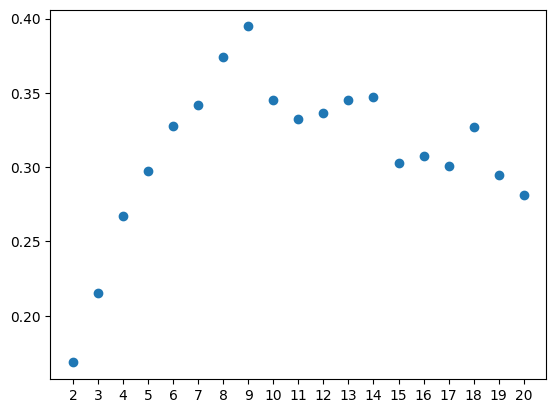

In [ ]:
## evaluation can be sum/average of distances of all datapoints to corresponding centers
## prefer clustering validation methods like Silhouette score

score = [silhouette_score(data, KMeans(n_clusters=k, n_init=10).fit(data).labels_) for k in range(2, 21)]
plt.scatter(list(range(2,21)),score)
plt.xticks(list(range(2,21)))
plt.show()

In [ ]:
## perform TSNE
tsne_coords = TSNE(n_components=2).fit_transform(data)

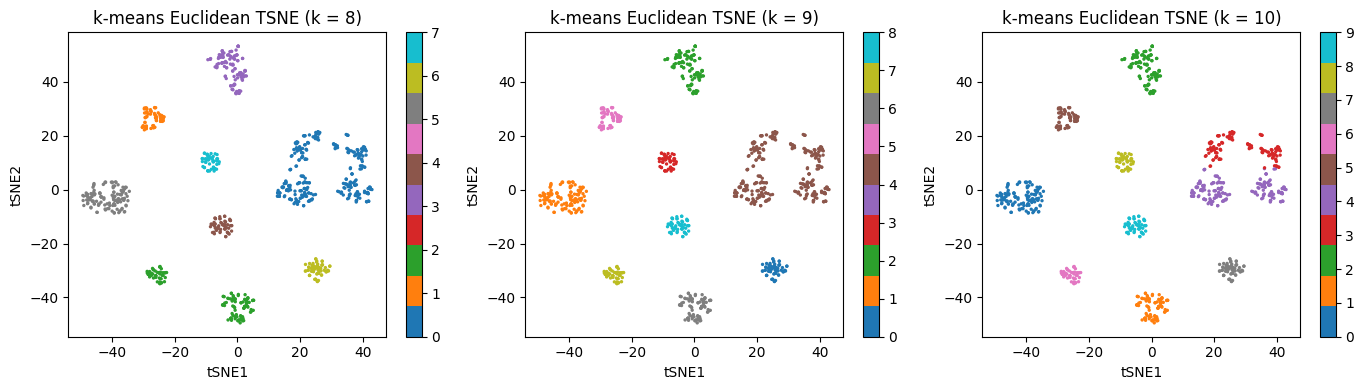

In [ ]:
## try to visualize clusters with TSNE

plt.figure(figsize=(14, 4))  # Adjust the figure size as needed

## first subplot (left)
plt.subplot(1, 3, 1)  # 1 row, 2 columns, plot 1 (left)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=KMeans(n_clusters=8, n_init=10).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("k-means Euclidean TSNE (k = 8)")
plt.colorbar()

## second subplot (right)
plt.subplot(1, 3, 2)  # 1 row, 2 columns, plot 2 (middle)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=KMeans(n_clusters=9, n_init=10).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("k-means Euclidean TSNE (k = 9)")
plt.colorbar()

## third subplot (right)
plt.subplot(1, 3, 3)  # 1 row, 2 columns, plot 3 (right)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=KMeans(n_clusters=10, n_init=10).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("k-means Euclidean TSNE (k = 10)")
plt.colorbar()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

### Perform clustering with different clustering methods implemented in Scikit Learn

In [ ]:
## the number of clusters should mainly rely on the definition of distance
## try at least two clustering methods other than KMeans

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

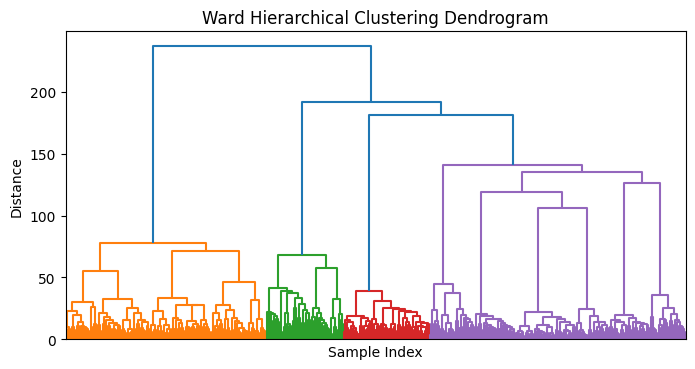

In [ ]:
linkage_matrix = linkage(data, method='ward')

plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, no_labels=True)
plt.title('Ward Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [ ]:
## specify a threshold for the number of clusters
threshold = 100  # adjust as needed

## get cluster assignments based on the threshold
clusters = fcluster(linkage_matrix, threshold, criterion='distance')
print("Cluster assignments:", np.unique(clusters))

Cluster assignments: [1 2 3 4 5 6 7 8 9]


In [ ]:
from sklearn.cluster import AgglomerativeClustering

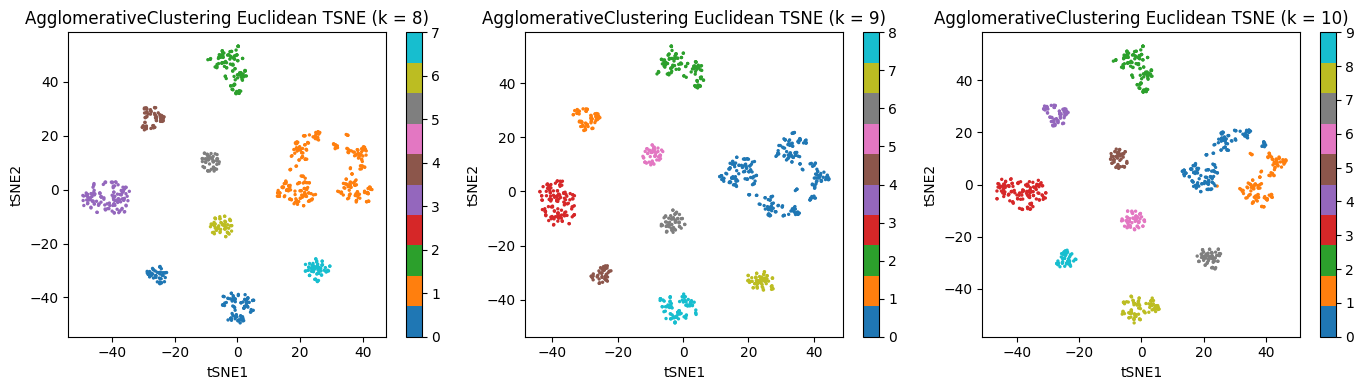

In [ ]:
## try to visualize clusters with TSNE

plt.figure(figsize=(14, 4))  # Adjust the figure size as needed

# First subplot (left)
plt.subplot(1, 3, 1)  # 1 row, 2 columns, plot 1 (left)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=8).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Euclidean TSNE (k = 8)")
plt.colorbar()

# Second subplot (right)
plt.subplot(1, 3, 2)  # 1 row, 2 columns, plot 2 (middle)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=9).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Euclidean TSNE (k = 9)")
plt.colorbar()

# Third subplot (right)
plt.subplot(1, 3, 3)  # 1 row, 2 columns, plot 3 (right)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=10).fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Euclidean TSNE (k = 10)")
plt.colorbar()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

### Try clustering with another distance metric (e.g. Cosine, Jaccard, etc.)

In [ ]:
## KMeans in scikit-learn does not accept distance metric other than Euclidean distance
## you could try doing KMeans with different distance metric
## this can be done either by using KMeans implementations in other packakges, or implement KMeans algorithm by yourself

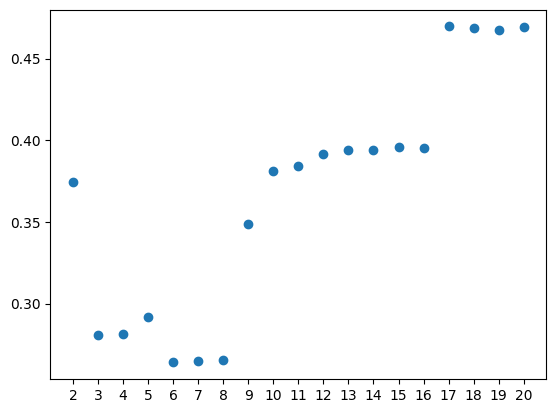

In [ ]:
score = [silhouette_score(data.astype(bool), AgglomerativeClustering(n_clusters=k, metric='jaccard', linkage='average').fit(data.astype(bool)).labels_, metric='jaccard') for k in range(2, 21)]
plt.scatter(list(range(2,21)),score)
plt.xticks(list(range(2,21)))
plt.show()

In [ ]:
## perform TSNE
tsne_coords = TSNE(n_components=2,metric='jaccard').fit_transform(data)

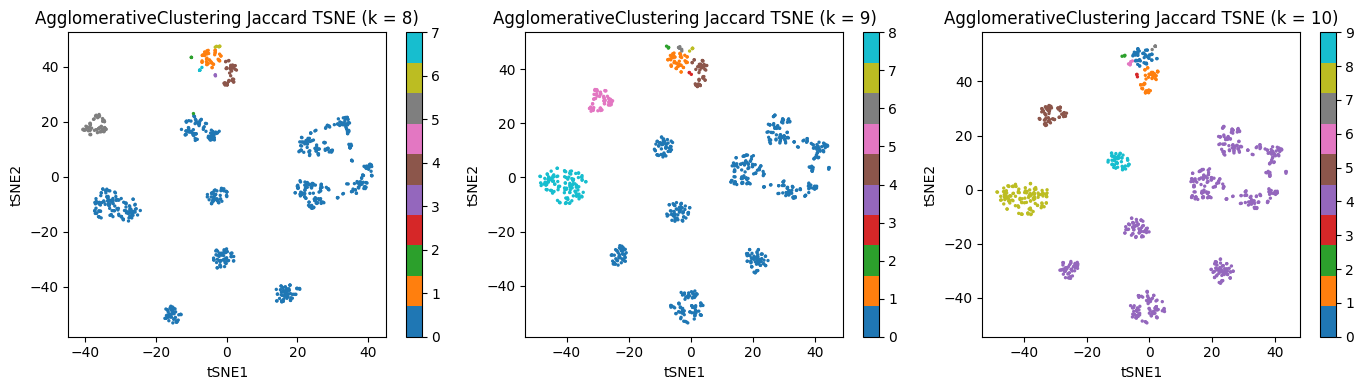

In [ ]:
## try to visualize clusters with TSNE

plt.figure(figsize=(14, 4))  # Adjust the figure size as needed

# First subplot (left)
plt.subplot(1, 3, 1)  # 1 row, 2 columns, plot 1 (left)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=8, metric='jaccard', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Jaccard TSNE (k = 8)")
plt.colorbar()

# Second subplot (right)
plt.subplot(1, 3, 2)  # 1 row, 2 columns, plot 2 (middle)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=9, metric='jaccard', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Jaccard TSNE (k = 9)")
plt.colorbar()

# Third subplot (right)
plt.subplot(1, 3, 3)  # 1 row, 2 columns, plot 3 (right)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=10, metric='jaccard', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Jaccard TSNE (k = 10)")
plt.colorbar()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

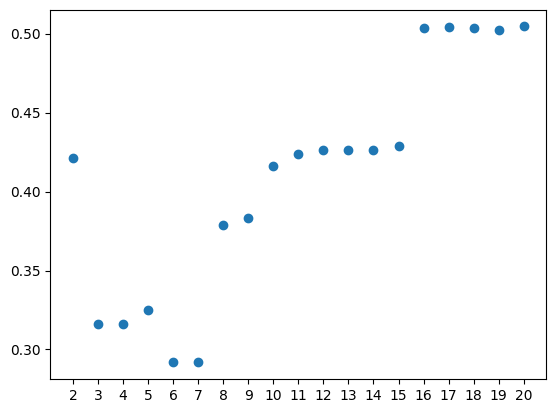

In [ ]:
score = [silhouette_score(data, AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average').fit(data).labels_, metric='cosine') for k in range(2, 21)]
plt.scatter(list(range(2,21)),score)
plt.xticks(list(range(2,21)))
plt.show()

In [ ]:
## perform TSNE
tsne_coords = TSNE(n_components=2,metric='cosine').fit_transform(data)

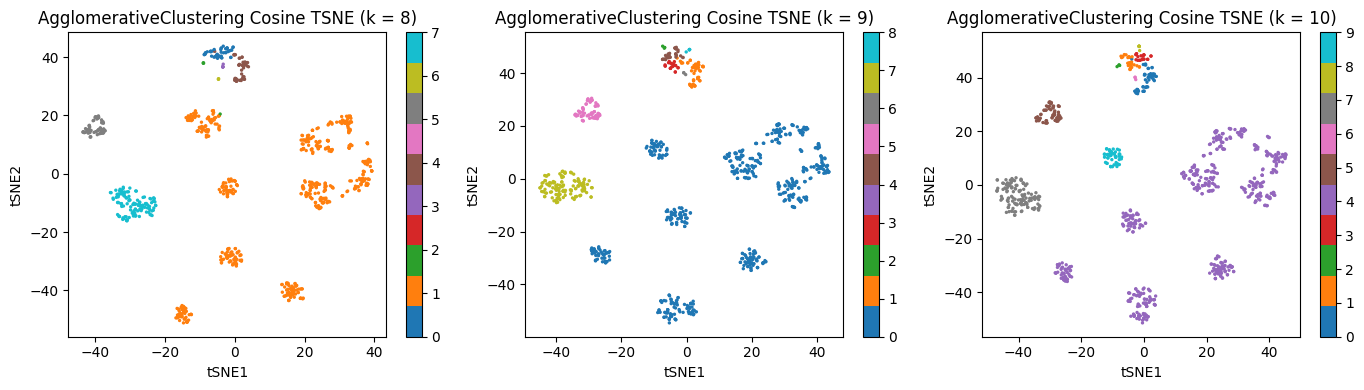

In [ ]:
## try to visualize clusters with TSNE

plt.figure(figsize=(14, 4))  # Adjust the figure size as needed

# First subplot (left)
plt.subplot(1, 3, 1)  # 1 row, 2 columns, plot 1 (left)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=8, metric='cosine', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Cosine TSNE (k = 8)")
plt.colorbar()

# Second subplot (right)
plt.subplot(1, 3, 2)  # 1 row, 2 columns, plot 2 (middle)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=9, metric='cosine', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Cosine TSNE (k = 9)")
plt.colorbar()

# Third subplot (right)
plt.subplot(1, 3, 3)  # 1 row, 2 columns, plot 3 (right)
tsne_coords = TSNE(n_components=2).fit_transform(data)
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=AgglomerativeClustering(n_clusters=10, metric='cosine', linkage='average').fit(data).labels_, s=2, cmap="tab10")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("AgglomerativeClustering Cosine TSNE (k = 10)")
plt.colorbar()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

### Visualize results using the dimensionality reduction (UMAP or tSNE) technique with respect to the cluster labels

In [ ]:
## visualize all of your clustering cases here OR you can also perform the visualization after each clustering method as shown above

### Compare clustering results

In [ ]:
## try to rationalize observed commonalities or differences with respect to clustering methods and distance metrics used